In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

In [ ]:

# CONFIGURATION


CSV_PATH = "Diabetes/train.csv"
IMAGE_DIR = "Diabetes/colored_images"

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Stage 1
FROZEN_EPOCHS = 5

# Stage 2
FINETUNE_EPOCHS = 15

LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_BACKBONE = 1e-5

WEIGHT_DECAY = 1e-4

NUM_CLASSES = 5

RANDOM_SEED = 42

MODEL_SAVE_PATH = "best_diabetic_retinopathy_model.pth"

NUM_WORKERS = 0

print("Configuration loaded.")

Configuration loaded.


In [7]:
print("Current working directory:")
print(os.getcwd())

print("\nCSV exists:", os.path.exists(CSV_PATH))
print("Image directory exists:", os.path.exists(IMAGE_DIR))

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")

Current working directory:
c:\Users\divya\Desktop\minorproject\Diabetes-prediction

CSV exists: True
Image directory exists: True


In [8]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


In [9]:
if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():

    DEVICE = torch.device("mps")

else:

    DEVICE = torch.device("cpu")


print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [10]:
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (3662, 2)

Columns:
['id_code', 'diagnosis']

First 5 rows:


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [11]:
CLASS_NAMES = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferate_DR"
]

CLASS_TO_INDEX = {
    "No_DR": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Proliferate_DR": 4
}

print("Actual medical mapping:")

for i, name in enumerate(CLASS_NAMES):
    print(f"{i} -> {name}")

Actual medical mapping:
0 -> No_DR
1 -> Mild
2 -> Moderate
3 -> Severe
4 -> Proliferate_DR


In [12]:
class_counts = df["diagnosis"].value_counts().sort_index()

print("Class distribution:\n")

for label, count in class_counts.items():
    print(
        f"{label} - "
        f"{CLASS_NAMES[label]:18} : "
        f"{count}"
    )

print("\nTotal:", len(df))

Class distribution:

0 - No_DR              : 1805
1 - Mild               : 370
2 - Moderate           : 999
3 - Severe             : 193
4 - Proliferate_DR     : 295

Total: 3662


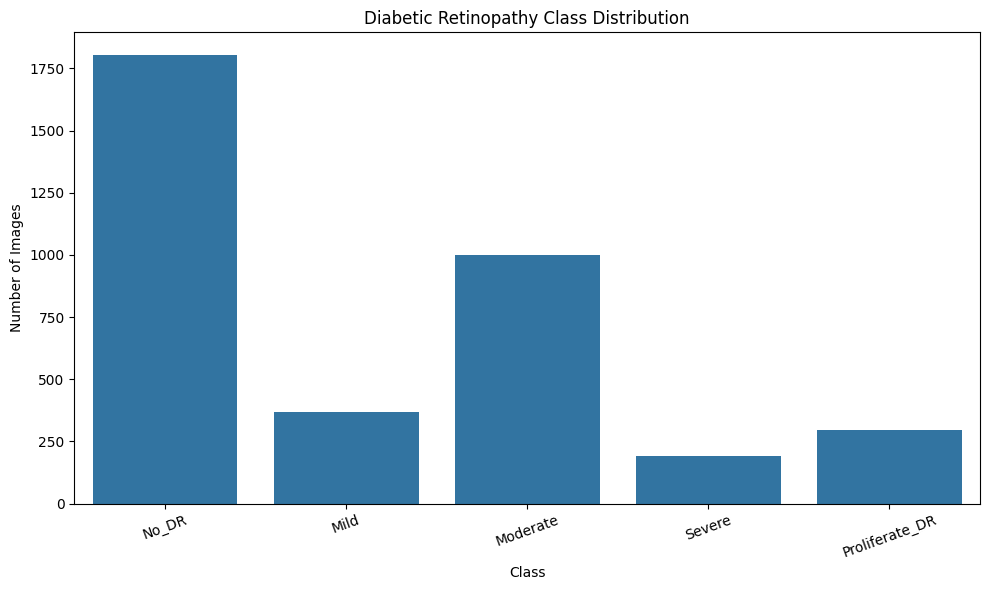

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=CLASS_NAMES,
    y=[
        class_counts.get(i, 0)
        for i in range(NUM_CLASSES)
    ]
)

plt.title("Diabetic Retinopathy Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [14]:
image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}

image_paths = {}

for root, dirs, files in os.walk(IMAGE_DIR):

    for file in files:

        extension = os.path.splitext(file)[1]

        if extension in image_extensions:

            image_id = os.path.splitext(file)[0]

            image_paths[image_id] = os.path.join(
                root,
                file
            )

print("Images found:", len(image_paths))

Images found: 3662


In [15]:
df["image_path"] = df["id_code"].map(image_paths)

missing = df["image_path"].isna().sum()

print("Total CSV entries:", len(df))
print("Matched images:", df["image_path"].notna().sum())
print("Missing images:", missing)

if missing > 0:

    print("\nMissing IDs:")

    display(
        df.loc[
            df["image_path"].isna(),
            ["id_code", "diagnosis"]
        ].head(20)
    )

    raise ValueError(
        "Some CSV entries do not have matching images."
    )

print("\nAll images matched successfully.")

Total CSV entries: 3662
Matched images: 3662
Missing images: 0

All images matched successfully.


In [16]:
class DiabeticRetinopathyDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]

        label = int(row["diagnosis"])

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:

            image = self.transform(image)

        return image, label

In [17]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [18]:
val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [19]:
indices = np.arange(len(df))

labels = df["diagnosis"].values


# 70% TRAIN
# 30% TEMPORARY

train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=RANDOM_SEED
)


# Split remaining 30% into:
# 15% validation
# 15% test

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    stratify=labels[temp_indices],
    random_state=RANDOM_SEED
)


train_df = df.iloc[train_indices].copy()
val_df = df.iloc[val_indices].copy()
test_df = df.iloc[test_indices].copy()


print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training: 2563
Validation: 549
Testing: 550
Total: 3662


In [20]:
print("TRAINING DISTRIBUTION")
print("=====================")

print(
    train_df["diagnosis"]
    .value_counts()
    .sort_index()
)


print("\nVALIDATION DISTRIBUTION")
print("=======================")

print(
    val_df["diagnosis"]
    .value_counts()
    .sort_index()
)


print("\nTEST DISTRIBUTION")
print("=================")

print(
    test_df["diagnosis"]
    .value_counts()
    .sort_index()
)

TRAINING DISTRIBUTION
diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

VALIDATION DISTRIBUTION
diagnosis
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

TEST DISTRIBUTION
diagnosis
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


In [21]:
train_dataset = DiabeticRetinopathyDataset(
    train_df,
    transform=train_transform
)

val_dataset = DiabeticRetinopathyDataset(
    val_df,
    transform=val_transform
)

test_dataset = DiabeticRetinopathyDataset(
    test_df,
    transform=val_transform
)


print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 2563
Validation dataset: 549
Test dataset: 550


In [22]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


print("DataLoaders created.")

DataLoaders created.


In [23]:
images, labels_batch = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels:", labels_batch[:10])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([2, 0, 2, 0, 0, 4, 0, 0, 2, 0])


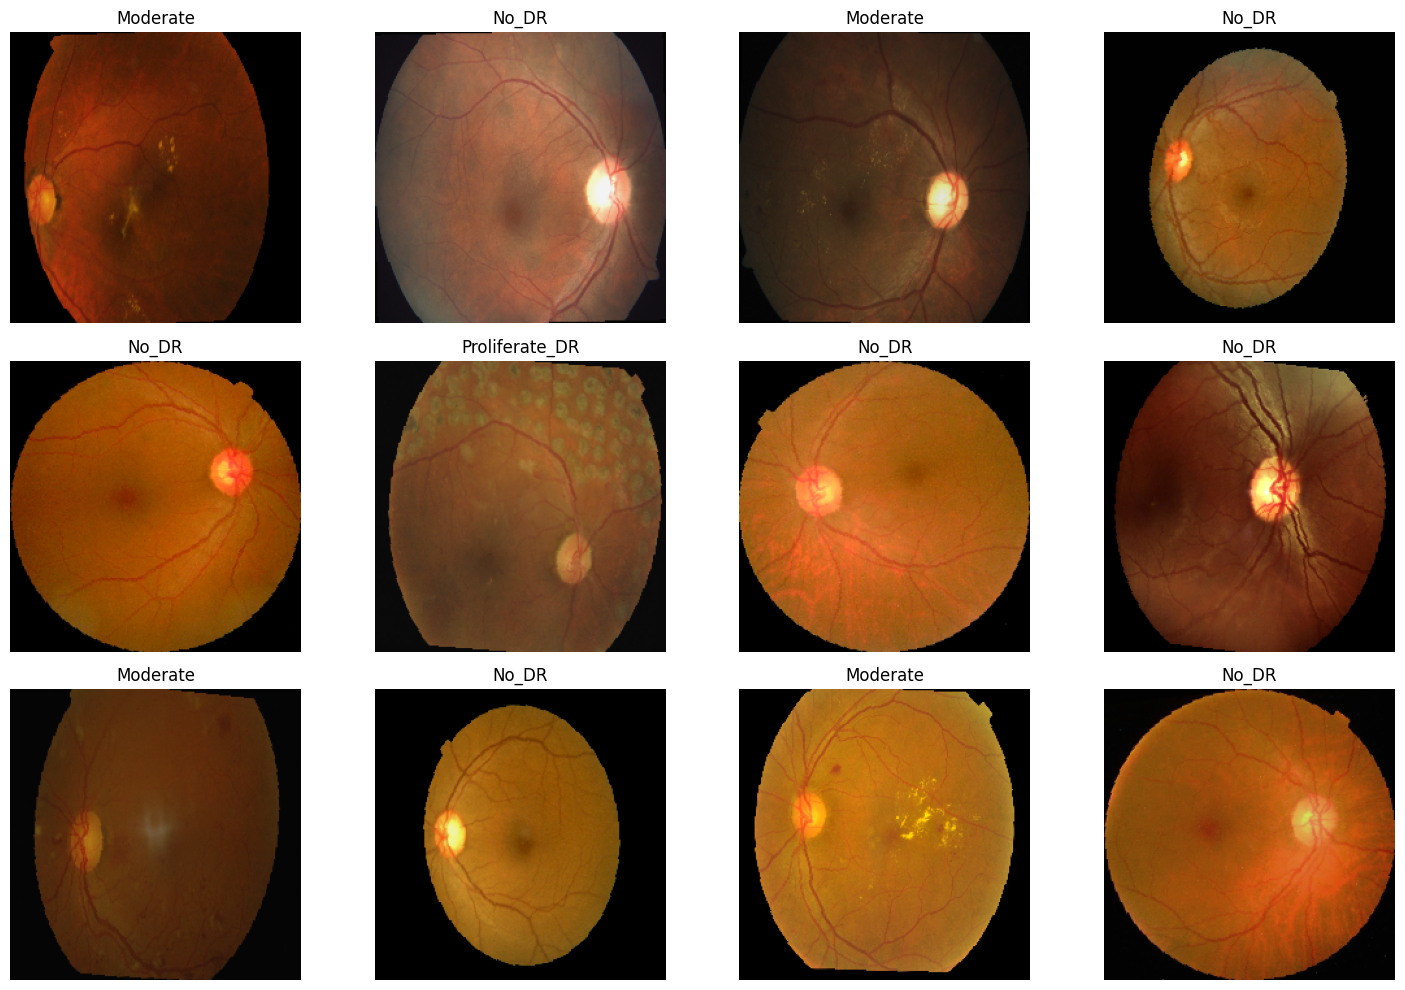

In [24]:
def denormalize(image):

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(image, 0, 1)


plt.figure(figsize=(15, 10))

for i in range(12):

    image = denormalize(
        images[i]
    )

    image = image.permute(
        1, 2, 0
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        CLASS_NAMES[
            labels_batch[i].item()
        ]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [25]:
train_labels = train_df["diagnosis"].values

class_counts_train = np.bincount(
    train_labels,
    minlength=NUM_CLASSES
)

print("Training class counts:\n")

for i in range(NUM_CLASSES):

    print(
        f"{i} - "
        f"{CLASS_NAMES[i]:18} : "
        f"{class_counts_train[i]}"
    )


# Inverse-frequency weighting

class_weights = (
    len(train_labels)
    /
    (
        NUM_CLASSES
        * class_counts_train
    )
)

print("\nCalculated class weights:\n")

for i in range(NUM_CLASSES):

    print(
        f"{CLASS_NAMES[i]:18} : "
        f"{class_weights[i]:.4f}"
    )

Training class counts:

0 - No_DR              : 1263
1 - Mild               : 259
2 - Moderate           : 699
3 - Severe             : 135
4 - Proliferate_DR     : 207

Calculated class weights:

No_DR              : 0.4059
Mild               : 1.9792
Moderate           : 0.7333
Severe             : 3.7970
Proliferate_DR     : 2.4763


In [26]:
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print(class_weights)

tensor([0.4059, 1.9792, 0.7333, 3.7970, 2.4763])


In [27]:
print("Loading pretrained EfficientNet-B0...")

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

print("Model loaded.")

Loading pretrained EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\divya/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:05<00:00, 3.90MB/s]


Model loaded.


In [28]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [29]:
for parameter in model.features.parameters():

    parameter.requires_grad = False


print("Backbone frozen.")

print(
    "Trainable classifier parameters:"
)

for name, parameter in model.classifier.named_parameters():

    print(
        name,
        parameter.shape
    )

Backbone frozen.
Trainable classifier parameters:
1.weight torch.Size([5, 1280])
1.bias torch.Size([5])


In [30]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY
)

print("Loss and optimizer ready.")

Loss and optimizer ready.


In [31]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    progress_bar = tqdm(
        loader,
        desc="Training"
    )


    for images, labels in progress_bar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = model(images)


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()


        batch_size = images.size(0)


        running_loss += (
            loss.item()
            * batch_size
        )


        predictions = outputs.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += batch_size


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    return epoch_loss, epoch_accuracy

In [32]:
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    all_predictions = []

    all_targets = []


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )


            outputs = model(images)


            loss = criterion(
                outputs,
                labels
            )


            running_loss += (
                loss.item()
                * images.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )


            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_targets.extend(
                labels.cpu().numpy()
            )


    all_predictions = np.array(
        all_predictions
    )

    all_targets = np.array(
        all_targets
    )


    loss = (
        running_loss
        /
        len(loader.dataset)
    )


    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )


    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return (
        loss,
        accuracy,
        macro_f1,
        all_targets,
        all_predictions
    )

In [33]:
best_val_f1 = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}


for epoch in range(FROZEN_EPOCHS):

    print("\n" + "=" * 60)

    print(
        f"STAGE 1 — EPOCH "
        f"{epoch + 1}/{FROZEN_EPOCHS}"
    )

    print("=" * 60)


    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )


    val_loss, val_acc, val_f1, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )


    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)


    print(
        f"\nTrain Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_acc:.4f}"
    )

    print(
        f"Validation Loss : {val_loss:.4f}"
    )

    print(
        f"Validation Acc  : {val_acc:.4f}"
    )

    print(
        f"Validation F1   : {val_f1:.4f}"
    )


    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            model.state_dict(),
            MODEL_SAVE_PATH
        )

        print("\n✓ Best model saved.")


STAGE 1 — EPOCH 1/5


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 1.3198
Train Accuracy  : 0.5774
Validation Loss : 1.2029
Validation Acc  : 0.7031
Validation F1   : 0.5185

✓ Best model saved.

STAGE 1 — EPOCH 2/5


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 1.1090
Train Accuracy  : 0.6719
Validation Loss : 1.1414
Validation Acc  : 0.7177
Validation F1   : 0.5609

✓ Best model saved.

STAGE 1 — EPOCH 3/5


...


Train Loss      : 1.0617
Train Accuracy  : 0.6769
Validation Loss : 1.0698
Validation Acc  : 0.7049
Validation F1   : 0.5538

STAGE 1 — EPOCH 4/5


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 0.9875
Train Accuracy  : 0.6937
Validation Loss : 1.0636
Validation Acc  : 0.7213
Validation F1   : 0.5739

✓ Best model saved.

STAGE 1 — EPOCH 5/5


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 0.9671
Train Accuracy  : 0.7105
Validation Loss : 1.0929
Validation Acc  : 0.7158
Validation F1   : 0.5501


In [34]:
print("Unfreezing EfficientNet backbone...")

for parameter in model.parameters():

    parameter.requires_grad = True


print("All model parameters are now trainable.")

Unfreezing EfficientNet backbone...
All model parameters are now trainable.


In [35]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE_BACKBONE,
    weight_decay=WEIGHT_DECAY
)

print(
    "Fine-tuning learning rate:",
    LEARNING_RATE_BACKBONE
)

Fine-tuning learning rate: 1e-05


In [36]:
for epoch in range(FINETUNE_EPOCHS):

    print("\n" + "=" * 60)

    print(
        f"STAGE 2 — FINE-TUNING EPOCH "
        f"{epoch + 1}/{FINETUNE_EPOCHS}"
    )

    print("=" * 60)


    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )


    val_loss, val_acc, val_f1, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )


    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)


    print(
        f"\nTrain Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_acc:.4f}"
    )

    print(
        f"Validation Loss : {val_loss:.4f}"
    )

    print(
        f"Validation Acc  : {val_acc:.4f}"
    )

    print(
        f"Validation F1   : {val_f1:.4f}"
    )


    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            model.state_dict(),
            MODEL_SAVE_PATH
        )

        print("\n✓ Best model saved.")


STAGE 2 — FINE-TUNING EPOCH 1/15


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 0.9398
Train Accuracy  : 0.7413
Validation Loss : 1.0653
Validation Acc  : 0.7395
Validation F1   : 0.5920

✓ Best model saved.

STAGE 2 — FINE-TUNING EPOCH 2/15


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 0.9106
Train Accuracy  : 0.7401
Validation Loss : 1.0449
Validation Acc  : 0.7286
Validation F1   : 0.5764

STAGE 2 — FINE-TUNING EPOCH 3/15


...


Train Loss      : 0.6839
Train Accuracy  : 0.7971
Validation Loss : 1.0120
Validation Acc  : 0.7377
Validation F1   : 0.5809

STAGE 2 — FINE-TUNING EPOCH 14/15


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 0.6536
Train Accuracy  : 0.7983
Validation Loss : 0.9955
Validation Acc  : 0.7577
Validation F1   : 0.5950

✓ Best model saved.

STAGE 2 — FINE-TUNING EPOCH 15/15


Training:   0%|          | 0/81 [00:00<?, ?it/s]


Train Loss      : 0.6606
Train Accuracy  : 0.8037
Validation Loss : 0.9661
Validation Acc  : 0.7559
Validation F1   : 0.5983

✓ Best model saved.


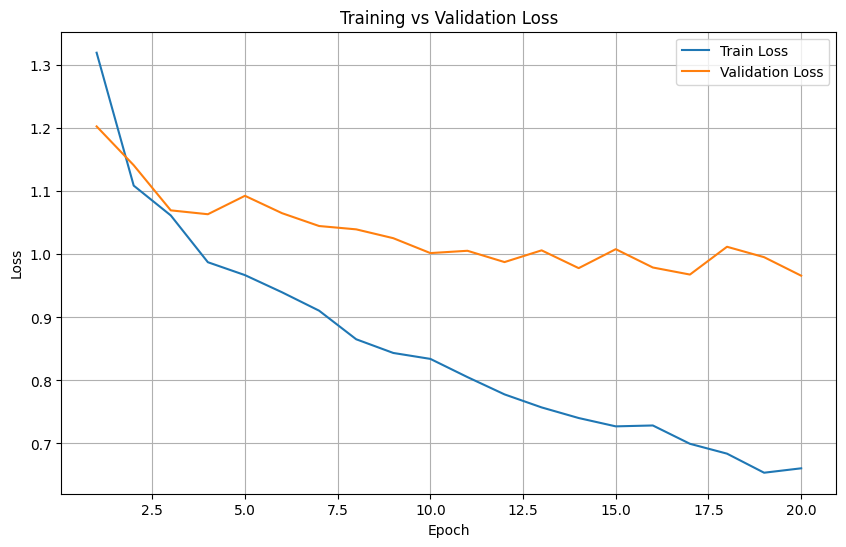

In [37]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid()

plt.show()

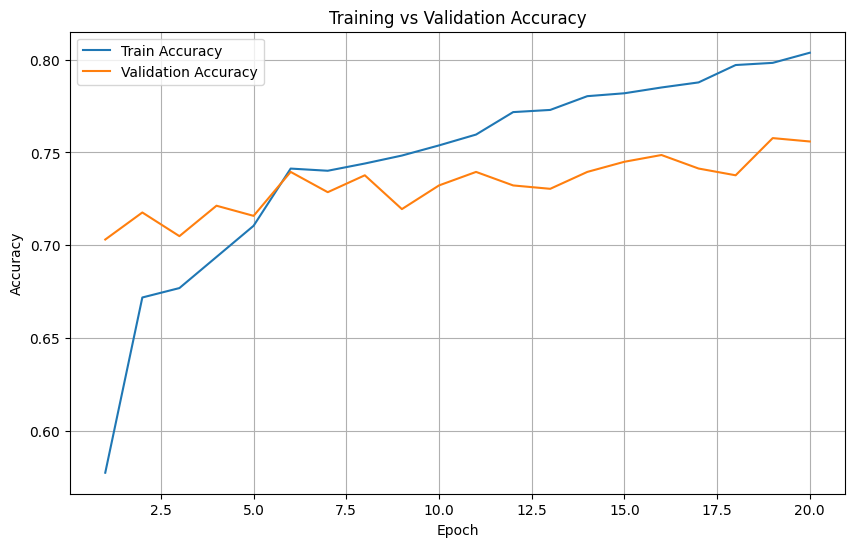

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid()

plt.show()

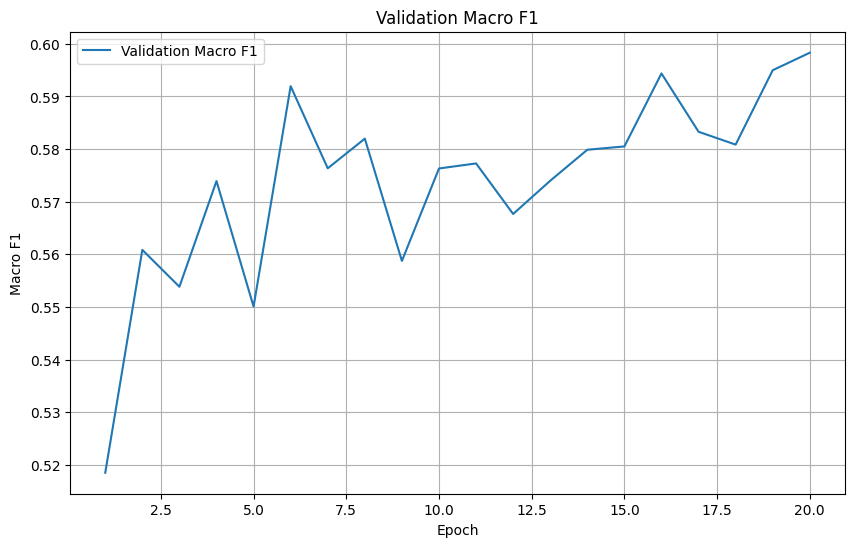

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["val_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.title("Validation Macro F1")

plt.legend()

plt.grid()

plt.show()

In [40]:
print("Loading best model...")

model.load_state_dict(
    torch.load(
        MODEL_SAVE_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded.")

Loading best model...
Best model loaded.


In [41]:
test_loss, test_accuracy, test_f1, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion
)

print("=" * 60)

print("FINAL TEST RESULTS")

print("=" * 60)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

print(
    f"Test Macro F1 : {test_f1:.4f}"
)

FINAL TEST RESULTS
Test Loss     : 0.8810
Test Accuracy : 0.7691
Test Macro F1 : 0.6109


In [42]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT
                precision    recall  f1-score   support

         No_DR     0.9527    0.9668    0.9597       271
          Mild     0.4853    0.5893    0.5323        56
      Moderate     0.7686    0.6200    0.6863       150
        Severe     0.3333    0.5172    0.4054        29
Proliferate_DR     0.4878    0.4545    0.4706        44

      accuracy                         0.7691       550
     macro avg     0.6056    0.6296    0.6109       550
  weighted avg     0.7851    0.7691    0.7733       550



In [43]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[262   8   1   0   0]
 [  6  33  15   1   1]
 [  6  20  93  21  10]
 [  0   0   4  15  10]
 [  1   7   8   8  20]]


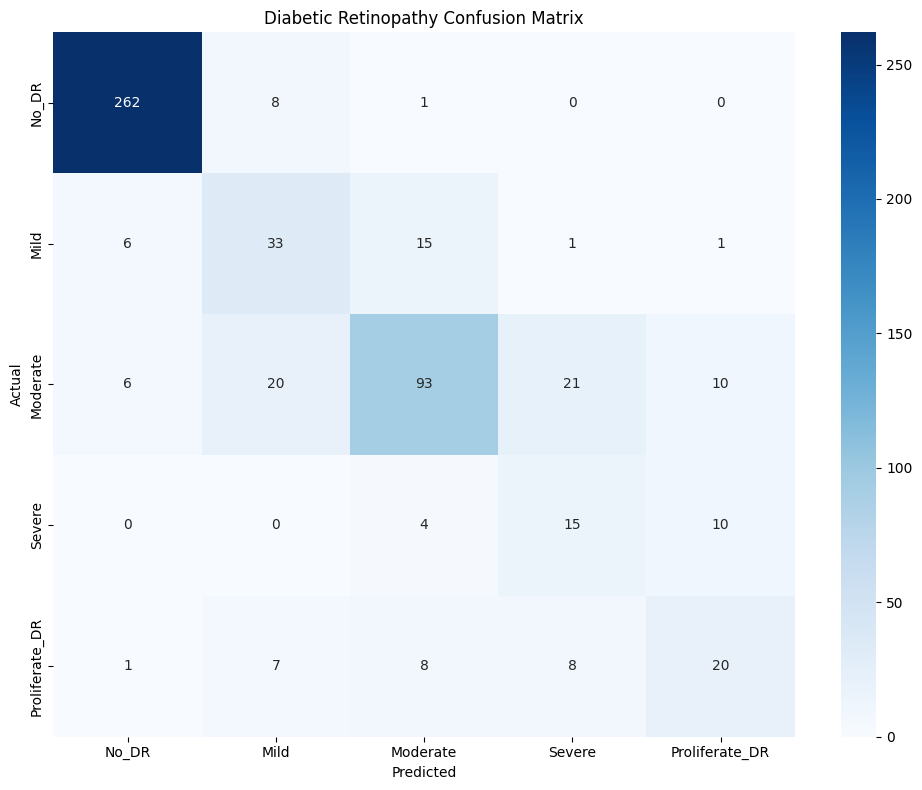

In [44]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Diabetic Retinopathy Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights="quadratic"
)

print("=" * 60)

print("QUADRATIC WEIGHTED KAPPA")

print("=" * 60)

print(
    f"QWK: {qwk:.4f}"
)

QUADRATIC WEIGHTED KAPPA
QWK: 0.8476


In [46]:
print("\n" + "=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print(
    f"Best Validation Macro F1 : "
    f"{best_val_f1:.4f}"
)

print(
    f"Test Accuracy            : "
    f"{test_accuracy:.4f}"
)

print(
    f"Test Macro F1            : "
    f"{test_f1:.4f}"
)

print(
    f"Quadratic Weighted Kappa : "
    f"{qwk:.4f}"
)

print(
    "\nModel file:"
)

print(
    os.path.abspath(
        MODEL_SAVE_PATH
    )
)

print(
    "\nConfusion matrix:"
)

print(
    os.path.abspath(
        "confusion_matrix.png"
    )
)


FINAL MODEL RESULTS
Best Validation Macro F1 : 0.5983
Test Accuracy            : 0.7691
Test Macro F1            : 0.6109
Quadratic Weighted Kappa : 0.8476

Model file:
c:\Users\divya\Desktop\minorproject\Diabetes-prediction\best_diabetic_retinopathy_model.pth

Confusion matrix:
c:\Users\divya\Desktop\minorproject\Diabetes-prediction\confusion_matrix.png


In [47]:
def predict_image(image_path):

    model.eval()

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = val_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(
        0
    )

    image_tensor = image_tensor.to(
        DEVICE
    )


    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[0]


    predicted_class = torch.argmax(
        probabilities
    ).item()


    confidence = probabilities[
        predicted_class
    ].item()


    print("=" * 50)

    print("PREDICTION")

    print("=" * 50)

    print(
        "Diagnosis:",
        CLASS_NAMES[predicted_class]
    )

    print(
        "Confidence:",
        f"{confidence * 100:.2f}%"
    )


    print("\nAll probabilities:")

    for i, probability in enumerate(
        probabilities
    ):

        print(
            f"{CLASS_NAMES[i]:18}: "
            f"{probability.item() * 100:.2f}%"
        )


    # Display image

    plt.figure(figsize=(7, 7))

    plt.imshow(image)

    plt.title(
        f"{CLASS_NAMES[predicted_class]} "
        f"({confidence * 100:.2f}%)"
    )

    plt.axis("off")

    plt.show()


    return (
        CLASS_NAMES[predicted_class],
        confidence,
        probabilities.cpu().numpy()
    )

PREDICTION
Diagnosis: No_DR
Confidence: 34.46%

All probabilities:
No_DR             : 34.46%
Mild              : 8.31%
Moderate          : 29.45%
Severe            : 13.87%
Proliferate_DR    : 13.90%


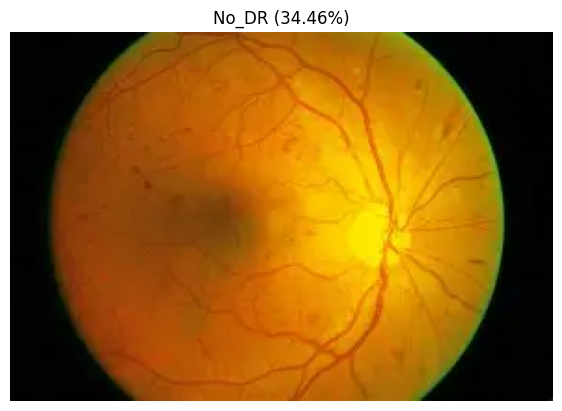

('No_DR',
 0.3446319103240967,
 array([0.3446319 , 0.08314238, 0.29452035, 0.13873711, 0.13896829],
       dtype=float32))

In [54]:
predict_image(
    "image.png"
)